# Digital Image Processing — Student Assignment Notebook

**Spring 2026**  
**Topic:** Image I/O, grayscale/binary, cropping (ROI), color spaces, and basic arithmetic operations

Fill in the fields below and complete **all TODO cells**.

**Student name:** Farangiz  
**Student ID:** 220849  
**Date:** 2026-02-06


In [1]:
# Imports (run once)
import os
import numpy as np
import matplotlib.pyplot as plt

import cv2

from skimage import data  # provides sample images (offline)

print("OpenCV:", cv2.__version__)


OpenCV: 4.13.0


In [6]:
from google.colab import files
uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]

Saving test_image.jpg to test_image.jpg


# Task 2.1

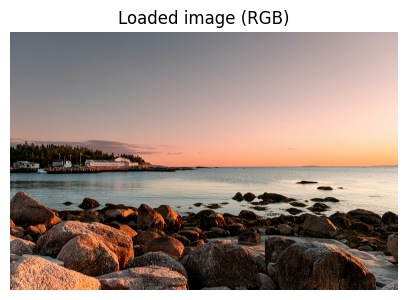

Image shape (H, W, C): (5152, 7728, 3) | dtype: uint8


In [7]:
IMAGE_PATH = "test_image.jpg"

def load_image(path=None):
    import cv2
    import os
    from skimage import data
    import numpy as np

    if path and os.path.exists(path):
        bgr = cv2.imread(path, cv2.IMREAD_COLOR)
        if bgr is None:
            raise ValueError(f"Failed to read: {path}")
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        return rgb
    return data.astronaut()
img = load_image(IMAGE_PATH)

import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Loaded image (RGB)")
plt.axis("off")
plt.show()

print("Image shape (H, W, C):", img.shape, "| dtype:", img.dtype)


In [8]:
h, w = img.shape[:2]

print("Top-left pixel:", img[0, 0])
print("Center pixel:", img[h//2, w//2])


Top-left pixel: [ 98 104 116]
Center pixel: [252 159 125]


# **Task 2.1 (Answer):**
- Top-left pixel: [R, G, B] — the intensity values of the color channels
- Center pixel: [R, G, B] — the intensity values at the center
- In an RGB image, each channel represents:
  - R — Red
  - G — Green
  - B — Blue


# Task 2.2

Reloaded shape: (5152, 7728, 3) | dtype: uint8


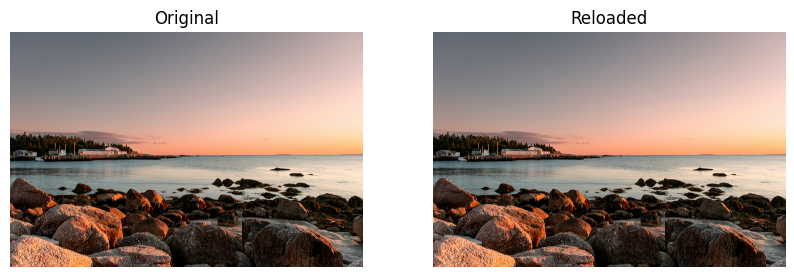

In [9]:
out_path = "output_saved.png"
import cv2
bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
cv2.imwrite(out_path, bgr)

reloaded_bgr = cv2.imread(out_path, cv2.IMREAD_COLOR)
reloaded_rgb = cv2.cvtColor(reloaded_bgr, cv2.COLOR_BGR2RGB)

print("Reloaded shape:", reloaded_rgb.shape, "| dtype:", reloaded_rgb.dtype)
import matplotlib.pyplot as plt
def show_side_by_side(img1, img2, title1="Image 1", title2="Image 2"):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img1); plt.title(title1); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(img2); plt.title(title2); plt.axis('off')
    plt.show()

show_side_by_side(img, reloaded_rgb, "Original", "Reloaded")


# **Task 2.2 (Answer):**
- The shape is the same: `(height, width, 3)`
- The data type is `uint8`
- The image was saved and reloaded without any loss


# Task 3.1

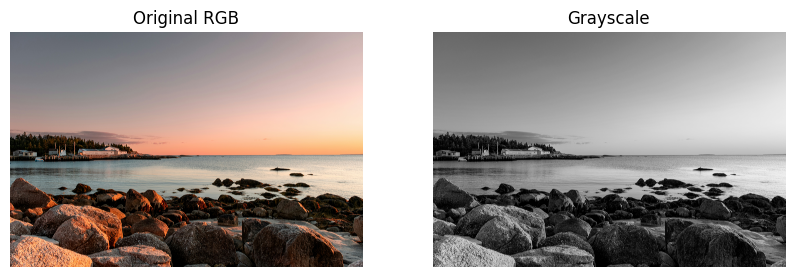

Gray image shape: (5152, 7728) | dtype: uint8


In [10]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()

print("Gray image shape:", gray.shape, "| dtype:", gray.dtype)


# **Task 3.1 (Answer):**
- The grayscale image has shape `(height, width)` — one channel instead of three
- The data type is `uint8`
- Each pixel now represents intensity (0 = black, 255 = white)


# Task 3.2

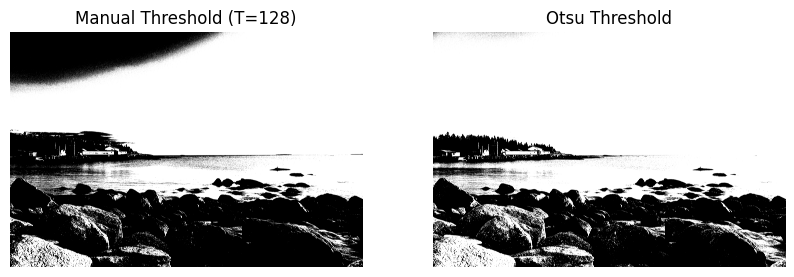

Otsu threshold value chosen by OpenCV: 100.0


In [11]:
th_manual = 128
_, binary_manual = cv2.threshold(gray, th_manual, 255, cv2.THRESH_BINARY)

_, binary_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(binary_manual, cmap="gray")
plt.title(f"Manual Threshold (T={th_manual})")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(binary_otsu, cmap="gray")
plt.title("Otsu Threshold")
plt.axis("off")
plt.show()

print("Otsu threshold value chosen by OpenCV:", _)


# **Task 3.2 (Answer):**
- Manual threshold: pixels greater than 128 become white, others black
- Otsu's threshold: automatically selects an optimal threshold based on histogram
- Comparison: Otsu's method adapts to the image, producing a more balanced binary result than a fixed threshold


# Task 4.1

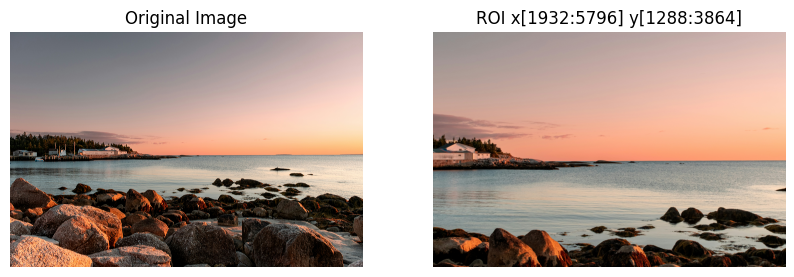

ROI shape: (2576, 3864, 3)


In [12]:
h, w = img.shape[:2]
x1, y1 = int(0.25*w), int(0.25*h)
x2, y2 = int(0.75*w), int(0.75*h)

roi = img[y1:y2, x1:x2].copy()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(roi)
plt.title(f"ROI x[{x1}:{x2}] y[{y1}:{y2}]")
plt.axis("off")
plt.show()

print("ROI shape:", roi.shape)


# **Task 4.1:**

1.   List item
2.   List item


- The ROI is a smaller part of the original image, cropped using array slicing
- Shape shows the height and width of the selected region
- Coordinates: img[y1:y2, x1:x2] → row-first, column-second (row = y, column = x)


# **Task 4.2:**
- In Python/NumPy, images are stored as 2D arrays (rows × columns)
- Accessing img[y, x] follows row-major order: first row (y), then column (x)
- If we used img[x, y], the slicing would be reversed and the image would be distorted


# Task 5.1

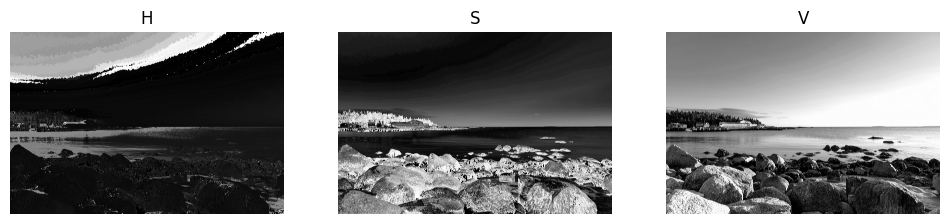

In [13]:
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

H, S, V = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]

plt.figure(figsize=(12,3))
for i, (ch, name) in enumerate([(H,"H"), (S,"S"), (V,"V")], start=1):
    plt.subplot(1,3,i)
    plt.imshow(ch, cmap="gray")
    plt.title(name)
    plt.axis("off")
plt.show()


# **Task 5.1:**
- H (Hue) represents the color type (0–179 in OpenCV)
- S (Saturation) represents the intensity of the color (0 = gray, 255 = fully saturated)
- V (Value) represents brightness (0 = black, 255 = full brightness)
- HSV separates color information (H) from intensity (V), which is useful for image processing


# Task 6.1

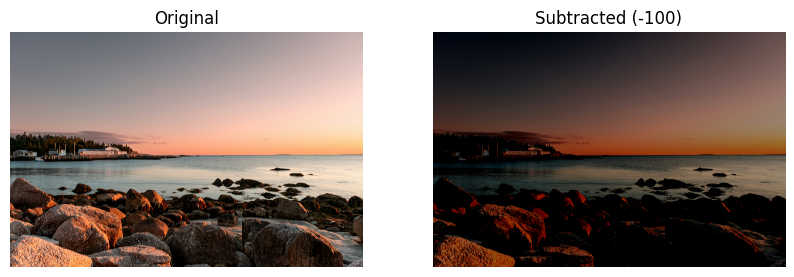

In [14]:
sub_val = 100
img_sub = cv2.subtract(img, sub_val)
show_side_by_side(img, img_sub, "Original", f"Subtracted (-{sub_val})")


# **Task 6.1 (Answer):**
1. Increasing sub_val makes the image darker because more intensity is subtracted from each pixel.
2. The image gets darker because pixel values are reduced, and any value below 0 is clipped to 0.


# Task 6.2

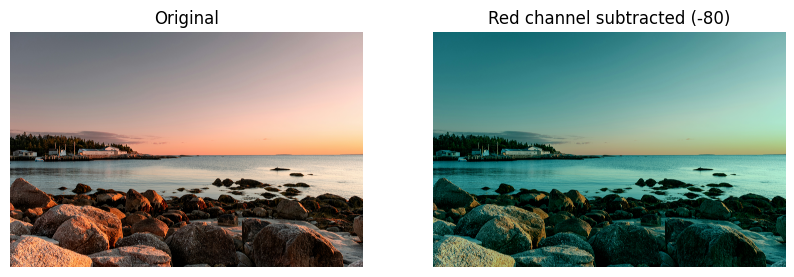

In [15]:
sub_val_r = 80

img_red_only = img.copy()
img_red_only[:,:,0] = cv2.subtract(img_red_only[:,:,0], sub_val_r)

show_side_by_side(img, img_red_only, "Original", f"Red channel subtracted (-{sub_val_r})")


# **Task 6.2 (Answer):**
- Only the Red channel is darkened, while Green and Blue channels remain unchanged.
- This selectively reduces red intensity, changing the color balance of the image.


# Task 6.3

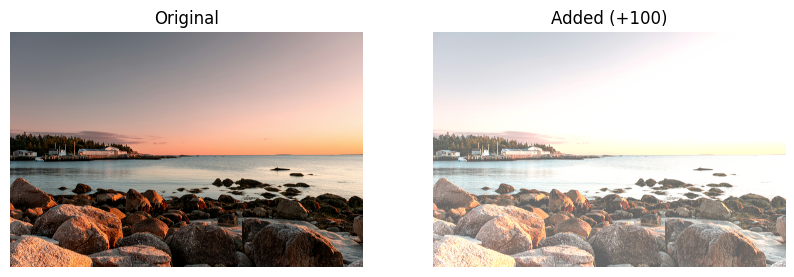

In [16]:
add_val = 100
img_add = cv2.add(img, add_val)
show_side_by_side(img, img_add, "Original", f"Added (+{add_val})")


# **Task 6.3 (Answer):**
1. Increasing add_val makes the image brighter because more intensity is added to each pixel.
2. The image gets brighter because pixel values increase, and any value above 255 is clipped to 255.


# Task 6.4

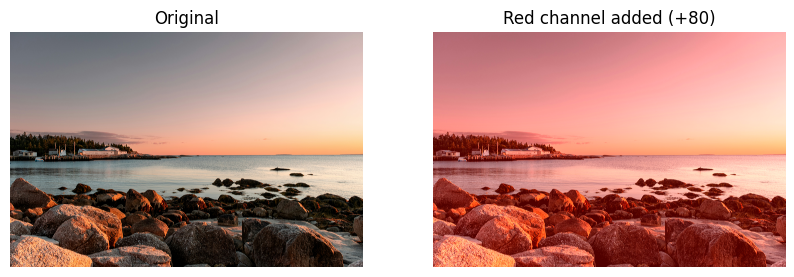

In [17]:
add_val_r = 80

img_red_only_add = img.copy()
img_red_only_add[:,:,0] = cv2.add(img_red_only_add[:,:,0], add_val_r)
show_side_by_side(img, img_red_only_add, "Original", f"Red channel added (+{add_val_r})")


# **Task 6.4 (Answer):**
- Only the Red channel is brightened, while Green and Blue remain unchanged.
- This increases red intensity, changing the overall color tone of the image toward red.


# Task 6.5

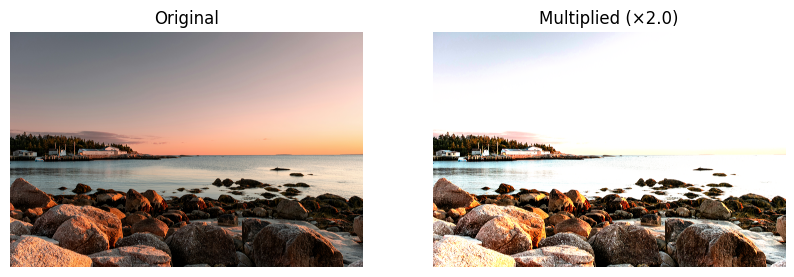

In [18]:
factor = 2.0

img_f = img.astype(np.float32)
img_mul = np.clip(img_f * factor, 0, 255).astype(np.uint8)
show_side_by_side(img, img_mul, "Original", f"Multiplied (×{factor})")


# **Task 6.5 (Answer):**
- Multiplying by a factor > 1 increases brightness/contrast; pixels get brighter.
- Multiplying by a factor < 1 reduces brightness/contrast; pixels get darker.
- Values are clipped to stay within 0–255 to avoid overflow.


# Task 6.6

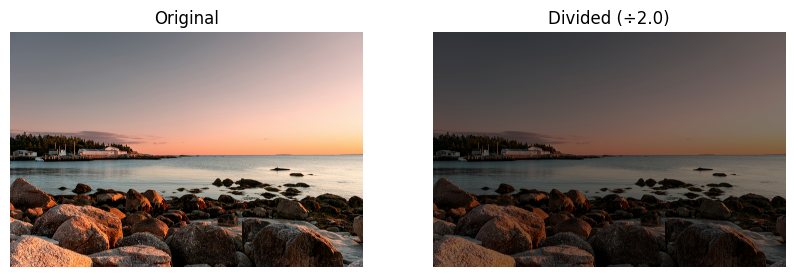

In [19]:
divisor = 2.0
img_f = img.astype(np.float32)
img_div = np.clip(img_f / divisor, 0, 255).astype(np.uint8)
show_side_by_side(img, img_div, "Original", f"Divided (÷{divisor})")


# **Task 6.6 (Answer):**
- Dividing by a number > 1 darkens the image because pixel values are reduced.
- Dividing by a number < 1 brightens the image because pixel values increase.
- Values are clipped to stay within 0–255.


# Mini-report



During this assignment, I learned how to perform basic image processing tasks using Python and OpenCV. I explored different ways to read, display, and save images, and learned how to manipulate images at the pixel level. Converting an image to grayscale and binary helped me understand how color information can be simplified for analysis. I also experimented with cropping regions of interest, which is useful for focusing on specific parts of an image.  

Working with color spaces, especially RGB and HSV, was very interesting because it showed how colors can be represented differently and how each channel contains unique information. The arithmetic operations were particularly helpful for understanding how images can be brightened, darkened, or have their contrast adjusted by modifying pixel values. I noticed that operations like adding or subtracting from a single channel can significantly change the appearance of the image, which is important in image editing and computer vision.  

One challenge I faced was remembering that OpenCV uses BGR by default, which can cause colors to appear incorrectly if not converted to RGB. Overall, this assignment was very practical, and it helped me feel more confident in working with digital images in Python.


# **Submission Checklist:**

1. This completed notebook (`.ipynb`) with all code cells executed.
2. Screenshots or outputs of:
   - Original RGB image
   - Grayscale image
   - Binary images (manual and Otsu)
   - Cropped ROI
   - HSV channels (H, S, V)
   - Arithmetic operations (subtract, add, multiply, divide, and single-channel edits)
3. All answers written in Markdown cells:
   - Task 2.1 → Task 6.6
   - Mini-report (Task 7)
